### Problem to solve :

Predict the function :

$$ y(x) = e^x $$

What we have to feed our neural network ?

ODE :

$$ \dfrac{dy}{dx} = y $$

Initial Condition :

$$ y(0) = 1 $$

Let us denote our neural network function by : $y_{NN}$

### Devising the loss function :

For this problem, we don't have an experimental data. Thus, we will have to rely on the boundary value and satisfy the ODE on the intermediate points in the domain. The loss function can have the following two pieces :

1. Boundary Loss :

$$ L_{BC} = (y_{NN}(0)-y(0))^2 = (y_{NN}(0)-1)^2 $$

2. ODE Loss :

$$ L_{ODE} = \dfrac{1}{N}\sum_i (y_{NN}'(x_i) - y_{NN}(x_i))^2 $$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
# Defining the domain as : [0,1]
x = torch.linspace(0.0,1.0,11,requires_grad=True).reshape(-1,1)
x

tensor([[0.0000],
        [0.1000],
        [0.2000],
        [0.3000],
        [0.4000],
        [0.5000],
        [0.6000],
        [0.7000],
        [0.8000],
        [0.9000],
        [1.0000]], grad_fn=<ViewBackward0>)

In [3]:
# Building a simple NN model
model = nn.Sequential(
    nn.Linear(1,20),
    nn.Tanh(),
    nn.Linear(20,20),
    nn.Tanh(),
    nn.Linear(20,1)
)

In [4]:
# Testing the model output types
test_1 = torch.tensor([5.0])
print(model(test_1))
test_2 = torch.arange(1.0,5.0).reshape(-1,1)
print(model(test_2))
print(test_2[0].item())

tensor([-0.0089], grad_fn=<ViewBackward0>)
tensor([[-0.2411],
        [-0.1835],
        [-0.1157],
        [-0.0568]], grad_fn=<AddmmBackward0>)
1.0


In [5]:
# Devising the loss function
def Loss(model,x,lmda):
    # lmda : rel. strength of the BC loss

    y = model(x)
    # print(f'y_test : {y}')

    # BC Loss
    loss_bc = (y[0]-1)**2
    # print(f'BC loss : {loss_bc}')

    # ODE loss
    dydx = torch.autograd.grad(
        outputs = y,
        inputs = x,
        grad_outputs=torch.ones_like(y),
        create_graph=True
    )[0]
    # grad_outputs is used to tell autograd which gradients to consider (all in this case)
    # torch.autograd.grad(...) gives a tuple of which the first element is the required torch-tensor, thus we use torch.autograd.grad(...)[0]
    loss_ode = torch.mean((dydx-y)**2)
    
    # total loss
    loss = loss_ode + lmda * loss_bc
    return y, loss

In [6]:
# Testing the loss function
x_test = torch.arange(0.0,0.5,0.1,requires_grad=True).reshape(-1,1)
print(Loss(model,x_test,lmda = 1.0))

(tensor([[-0.1842],
        [-0.1990],
        [-0.2118],
        [-0.2225],
        [-0.2309]], grad_fn=<AddmmBackward0>), tensor([1.4131], grad_fn=<AddBackward0>))


In [7]:
# Defining the optimizer (stochastic gradient descent here)
optim = torch.optim.SGD(model.parameters(),lr = 0.01)

In [8]:
# training the model
N_epochs = 10000
loss_arr = []
for epoch in range(N_epochs):
    # forward pass and loss
    y, loss = Loss(model,x,lmda = 1.0)
    loss_arr.append(loss.item())

    # optimization step
    loss.backward()
    optim.step()
    optim.zero_grad()

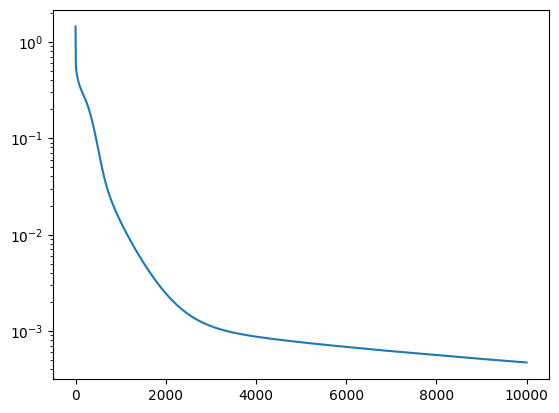

In [9]:
plt.semilogy(loss_arr)
plt.show()

In [10]:
print(f"Initial Loss : {loss_arr[0]}")
print(f"Final Loss : {loss_arr[-1]}")

Initial Loss : 1.4373232126235962
Final Loss : 0.00047137425281107426


In [11]:
print(f"Original x : {x}")
print(f"Flattened x : {x.flatten()}")
print(f"Detached x : {x.flatten().detach()}")
print(f"Converted to numpy object : {x.flatten().detach().numpy()}")

Original x : tensor([[0.0000],
        [0.1000],
        [0.2000],
        [0.3000],
        [0.4000],
        [0.5000],
        [0.6000],
        [0.7000],
        [0.8000],
        [0.9000],
        [1.0000]], grad_fn=<ViewBackward0>)
Flattened x : tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000], grad_fn=<ViewBackward0>)
Detached x : tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000])
Converted to numpy object : [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [12]:
# Exact solution in the domain
y_exact = torch.exp(x)

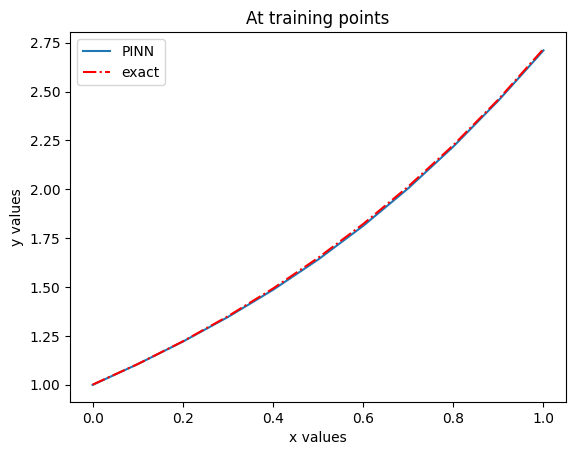

In [13]:
# Visualising the solution obtained by PINN against the exact solution
plt.plot(x.flatten().detach(),y.flatten().detach(),label = 'PINN')
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),label = 'exact',c = 'red',ls = '-.')
plt.legend()
plt.title("At training points")
plt.xlabel("x values")
plt.ylabel("y values")
plt.show()

### Comparing predicted function at different set of x values

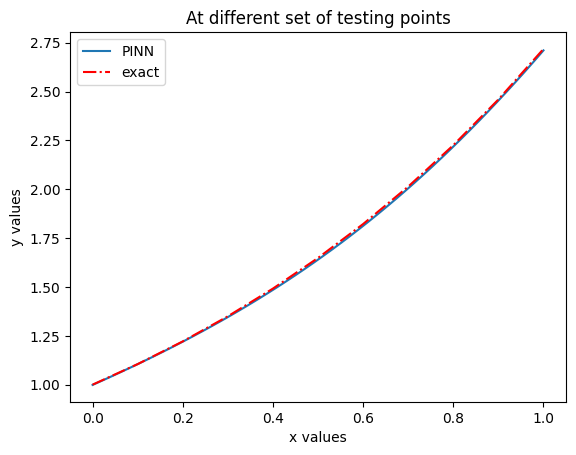

In [14]:
x_test = torch.linspace(0.0,1.0,50).reshape(-1,1)
y_test = model(x_test)
plt.plot(x_test.flatten().detach(),y_test.flatten().detach(),label = 'PINN')
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),label = 'exact',c = 'red',ls = '-.')
plt.legend()
plt.title("At different set of testing points")
plt.xlabel("x values")
plt.ylabel("y values")
plt.show()

### Effect of changing relative weight for BC loss term

In [15]:
# defining the entire PINN again
def PINN(N_epochs,lmda,x):
    # defining the model
    model = nn.Sequential(
        nn.Linear(1,20),
        nn.Tanh(),
        nn.Linear(20,20),
        nn.Tanh(),
        nn.Linear(20,1)        
    )

    # optimizer
    optim = torch.optim.SGD(model.parameters(),lr = 0.01)

    # training the model
    loss_arr = []
    for epoch in range(N_epochs):
        # forward pass and loss
        y, loss = Loss(model,x,lmda)
        loss_arr.append(loss.item())

        # optimization step
        loss.backward()
        optim.step()
        optim.zero_grad()
    
    # prediction using PINN
    y = model(x)

    return y, loss_arr

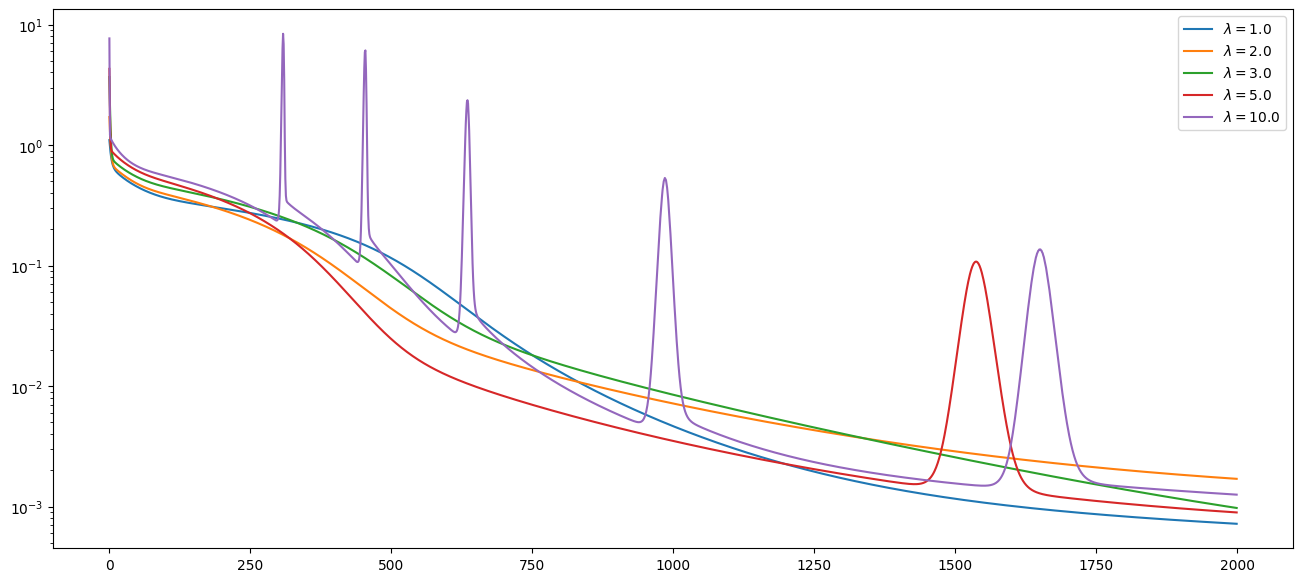

In [16]:
x = torch.linspace(0.0,1.0,11,requires_grad=True).reshape(-1,1)
lmdas = torch.tensor([1.0,2.0,3.0,5.0,10.0])
plt.figure(figsize = (16,7))
y_all = []
loss_all = []
for lmda in lmdas:
    y, loss_arr = PINN(2000, lmda, x)
    loss_all.append(loss_arr)
    y_all.append(y)
    plt.semilogy(loss_arr, label = f"$\lambda = ${lmda}")
    plt.legend()
plt.show()

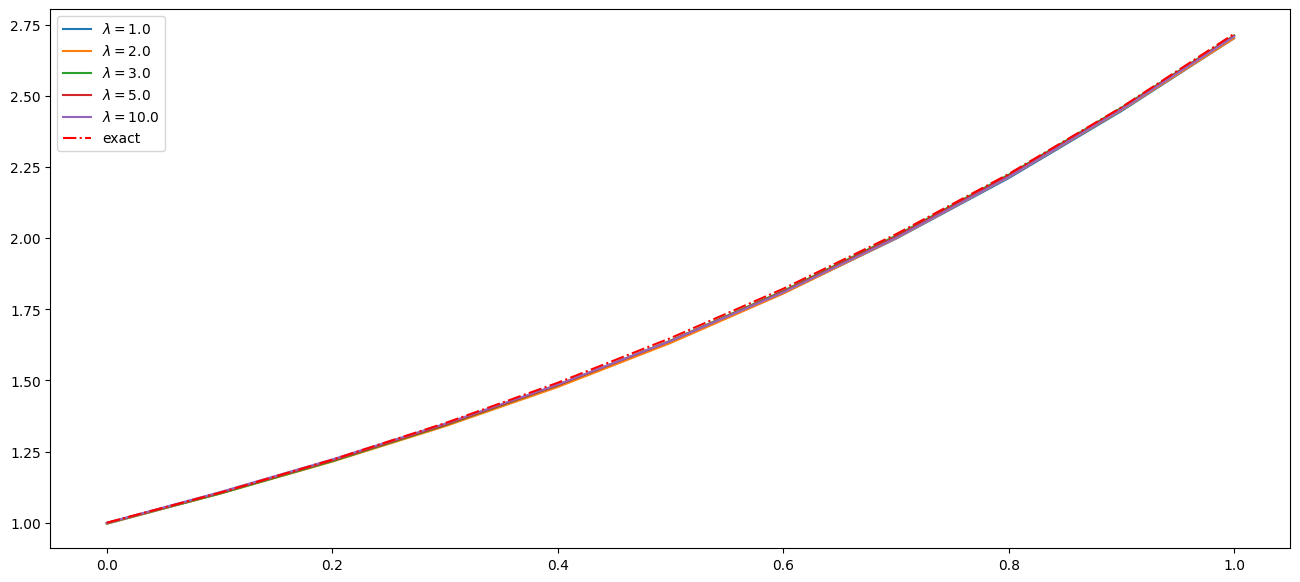

In [17]:
plt.figure(figsize = (16,7))
for i in range(len(lmdas)):
    plt.plot(x.flatten().detach(),y_all[i].flatten().detach(),label = f"$\lambda = ${lmdas[i]}")
plt.plot(x.flatten().detach(),y_exact.flatten().detach(),label = 'exact',c = 'red',ls = '-.')
plt.legend()
plt.show()